In [1]:
# %% [markdown]
# # Weather + Production Analysis Notebook
# - Cities: Oslo, Kristiansand, Trondheim, Tromsø, Bergen (price areas NO1..NO5)
# - Uses Open-Meteo ERA5 archive API for hourly reanalysis
# - Analyses: DCT high-pass temperature outliers (SPC), precipitation LOF anomalies,
#   STL decomposition (production data), Spectrogram (production data)

# %% code
# Basic imports
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.tsa.seasonal import STL
from scipy.signal import spectrogram
import os
from typing import Tuple, Dict, Any

# Make plots prettier by default (but not heavy styling)
plt.rcParams['figure.figsize'] = (14,4)
#plt.rcParams['tight_layout'] = True

# %% [markdown]
# ## 1) Cities DataFrame (price area codes + center coords)
# We'll use the typical mapping for Norway price areas (NO1..NO5).
# The coordinates below are approximate city centre coordinates you can refine if needed.

# %% code
cities = [
    {"price_area": "NO1", "city": "Oslo",          "latitude": 59.9139, "longitude": 10.7522},
    {"price_area": "NO2", "city": "Kristiansand",  "latitude": 58.1467, "longitude": 7.9956},
    {"price_area": "NO3", "city": "Trondheim",     "latitude": 63.4305, "longitude": 10.3951},
    {"price_area": "NO4", "city": "Tromsø",        "latitude": 69.6492, "longitude": 18.9553},
    {"price_area": "NO5", "city": "Bergen",        "latitude": 60.3942, "longitude": 5.3221},
]
df_cities = pd.DataFrame(cities)
df_cities = df_cities[["price_area", "city", "longitude", "latitude"]]  # requested column order
df_cities


/Users/mobashraabeer/miniconda3/envs/D2D_env/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


,price_area,city,longitude,latitude
0,NO1,Oslo,10.7522,59.9139
1,NO2,Kristiansand,7.9956,58.1467
2,NO3,Trondheim,10.3951,63.4305
3,NO4,Tromsø,18.9553,69.6492
4,NO5,Bergen,5.3221,60.3942


In [3]:
import requests
import pandas as pd

def fetch_weather_data(latitude: float,
                       longitude: float,
                       year: int,
                       timezone: str = "UTC",
                       verbose: bool = True) -> pd.DataFrame:
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    variables = [
        "temperature_2m",
        "precipitation",
        "wind_speed_10m",
        "wind_gusts_10m",
        "wind_direction_10m"
    ]
    hourly = ",".join(variables)
    base = "https://archive-api.open-meteo.com/v1/era5"
    params = (
        f"?latitude={latitude}&longitude={longitude}"
        f"&start_date={start_date}&end_date={end_date}"
        f"&hourly={hourly}&timezone={timezone}"
    )
    url = base + params
    if verbose:
        print("Fetching:", url)

    # ✅ Safe request
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        js = resp.json()
    except Exception as e:
        print(f"❌ Failed to fetch data: {e}")
        return pd.DataFrame()  # return empty DataFrame instead of crashing

    if "hourly" not in js or "time" not in js["hourly"]:
        print("⚠️ Unexpected JSON structure.")
        return pd.DataFrame()

    hourly_js = js["hourly"]
    df = pd.DataFrame({"time": pd.to_datetime(hourly_js["time"])})
    for v in variables:
        df[v] = hourly_js.get(v)
    df = df.sort_values("time").reset_index(drop=True)
    return df


bergen2019 = fetch_weather_data(latitude=60.3942, longitude=5.3221, year=2019, timezone="UTC")
bergen2019.head()


Fetching: https://archive-api.open-meteo.com/v1/era5?latitude=60.3942&longitude=5.3221&start_date=2019-01-01&end_date=2019-12-31&hourly=temperature_2m,precipitation,wind_speed_10m,wind_gusts_10m,wind_direction_10m&timezone=UTC


,time,temperature_2m,precipitation,wind_speed_10m,wind_gusts_10m,wind_direction_10m
0,2019-01-01 00:00:00,5.8,0.2,41.0,107.3,278
1,2019-01-01 01:00:00,6.1,0.7,42.0,112.0,286
2,2019-01-01 02:00:00,6.4,0.5,40.9,105.8,298
3,2019-01-01 03:00:00,5.9,1.1,41.2,110.2,315
4,2019-01-01 04:00:00,5.8,0.7,44.1,107.3,322


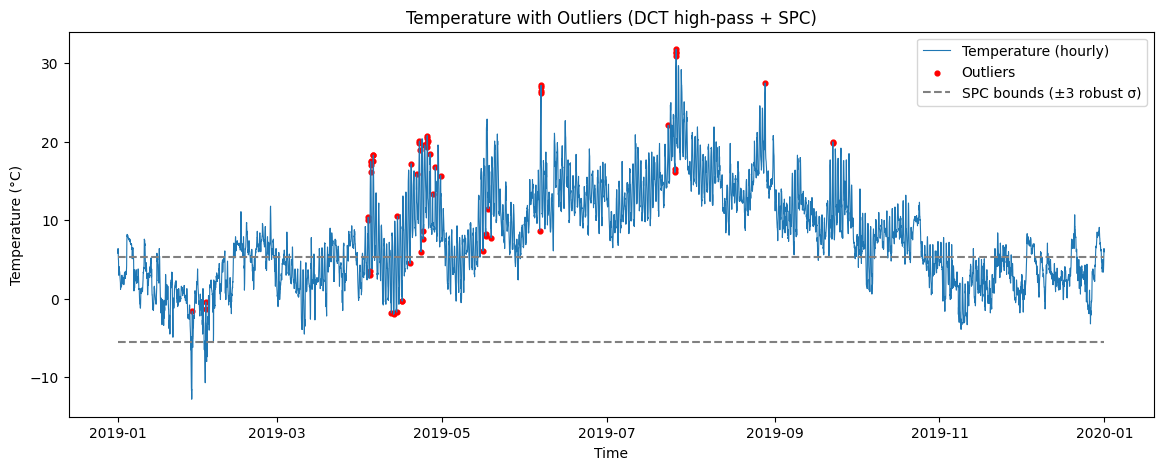

59 outliers detected out of 8760 samples


In [7]:
# %% [markdown]
# ## 3) Temperature outlier detection using DCT high-pass + SPC bounds (robust stats)
# This function:
# - accepts DataFrame with 'time' and temperature column
# - performs DCT, zeroes low-frequency coefficients up to cutoff (freq_cutoff)
# - reconstructs the high-passed signal (SATV, not plotted)
# - computes robust median & MAD -> robust std estimate
# - defines SPC boundaries = median ± n_std * robust_std
# - returns a plot with temperature time series and outliers marked, plus a summary dict
#
# Defaults: freq_cutoff in terms of number of DCT coefficients (sensible default for hourly year):
# - For hourly data (≈8760 points), a seasonal cutoff ~24*30 (monthly) works well as default.
# - n_std default = 3

# %% code
def temp_outlier_dct_spc(df: pd.DataFrame,
                         temp_col: str = "temperature_2m",
                         time_col: str = "time",
                         freq_cutoff: int = 24 * 30,
                         n_std: float = 3.0,
                         plot: bool = True) -> Dict[str, Any]:
    # prepare data
    df = df.sort_values(time_col).reset_index(drop=True)
    temps = df[temp_col].to_numpy(dtype=float)
    n = len(temps)
    if freq_cutoff >= n:
        raise ValueError("freq_cutoff must be less than number of samples")
    # DCT
    coeffs = dct(temps, norm="ortho")
    # Zero-out low-frequency (seasonal) components up to freq_cutoff
    hp_coeffs = coeffs.copy()
    hp_coeffs[:freq_cutoff] = 0
    residual = idct(hp_coeffs, norm="ortho")
    # robust stats on residual
    med = np.median(residual)
    mad = np.median(np.abs(residual - med))
    robust_std = mad * 1.4826  # consistent estimator for normal distribution
    upper = med + n_std * robust_std
    lower = med - n_std * robust_std
    outlier_mask = (residual > upper) | (residual < lower)
    # plotting
    if plot:
        plt.figure(figsize=(14,5))
        plt.plot(df[time_col], temps, label="Temperature (hourly)", linewidth=0.8)
        plt.scatter(df[time_col][outlier_mask], temps[outlier_mask], color="red", s=12, label="Outliers")
        # Show SPC boundaries on the temperature y-axis by mapping residual bounds to original temp scale:
        # Because residuals are in same units and represent high-frequency part, plotting horizontal lines
        # at median +/- bounds is informative to interpret outliers relative to mean high-freq dev.
        plt.hlines([upper, lower], xmin=df[time_col].min(), xmax=df[time_col].max(),
           colors="gray", linestyles="--", label=f"SPC bounds (±{n_std} robust σ)")

        plt.legend()
        plt.title("Temperature with Outliers (DCT high-pass + SPC)")
        plt.xlabel("Time")
        plt.ylabel("Temperature (°C)")
        plt.show()
    summary = {
        "n_samples": n,
        "n_outliers": int(outlier_mask.sum()),
        "outlier_fraction": float(outlier_mask.sum() / max(1, n)),
        "median_residual": float(med),
        "robust_std_residual": float(robust_std),
        "upper_bound_residual": float(upper),
        "lower_bound_residual": float(lower),
        "outlier_indices": np.where(outlier_mask)[0],
        "outlier_times": df[time_col][outlier_mask].tolist()
    }
    return summary

# Example call (after fetching data):
summary = temp_outlier_dct_spc(bergen2019, freq_cutoff=24*30, n_std=3)
print(f"{summary['n_outliers']} outliers detected out of {summary['n_samples']} samples")


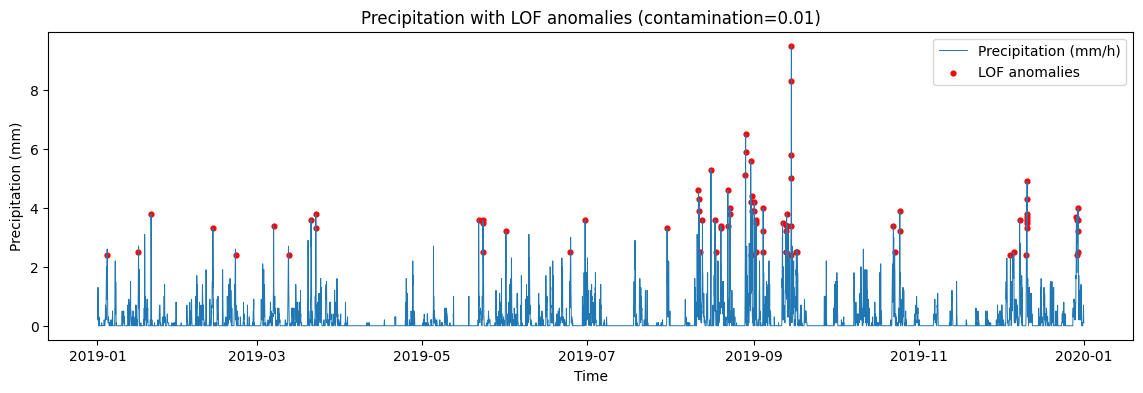

86 precip anomalies


In [13]:
# %% [markdown]
# ## 4) Precipitation anomaly detection using Local Outlier Factor (LOF)
# - We will apply LOF to the precipitation column.
# - Parameter `outlier_prop` defines contamination parameter for LOF (default 0.01 = 1%).
# - Returns a plot with anomalies marked and summary dict.

# %% code
def precip_lof_anomalies(df: pd.DataFrame,
                         precip_col: str = "precipitation",
                         time_col: str = "time",
                         outlier_prop: float = 0.01,
                         plot: bool = True) -> Dict[str, Any]:
    df = df.sort_values(time_col).reset_index(drop=True)
    X = df[[precip_col]].fillna(0).to_numpy(dtype=float)  # LOF expects finite numbers
    n_samples = len(X)
    # choose neighbors: typical heuristic 20 or sqrt(n)
    n_neighbors = min(max(5, int(np.sqrt(n_samples))), 50)
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=outlier_prop)
    y_pred = lof.fit_predict(X)  # -1 = outlier, 1 = inlier
    anomaly_mask = (y_pred == -1)
    if plot:
        plt.figure(figsize=(14,4))
        plt.plot(df[time_col], df[precip_col], label="Precipitation (mm/h)", linewidth=0.7)
        plt.scatter(df[time_col][anomaly_mask], df[precip_col][anomaly_mask], color="red", s=12, label="LOF anomalies")
        plt.title(f"Precipitation with LOF anomalies (contamination={outlier_prop})")
        plt.xlabel("Time")
        plt.ylabel("Precipitation (mm)")
        plt.legend()
        plt.show()
    scores = -lof.negative_outlier_factor_  # higher => more outlier
    summary = {
        "n_samples": n_samples,
        "n_anomalies": int(anomaly_mask.sum()),
        "anomaly_fraction": float(anomaly_mask.sum() / max(1, n_samples)),
        "anomaly_indices": np.where(anomaly_mask)[0],
        "anomaly_times": df[time_col][anomaly_mask].tolist(),
        "scores": scores
    }
    return summary

# Example call:
pa = precip_lof_anomalies(bergen2019, outlier_prop=0.01)
print(pa["n_anomalies"], "precip anomalies")


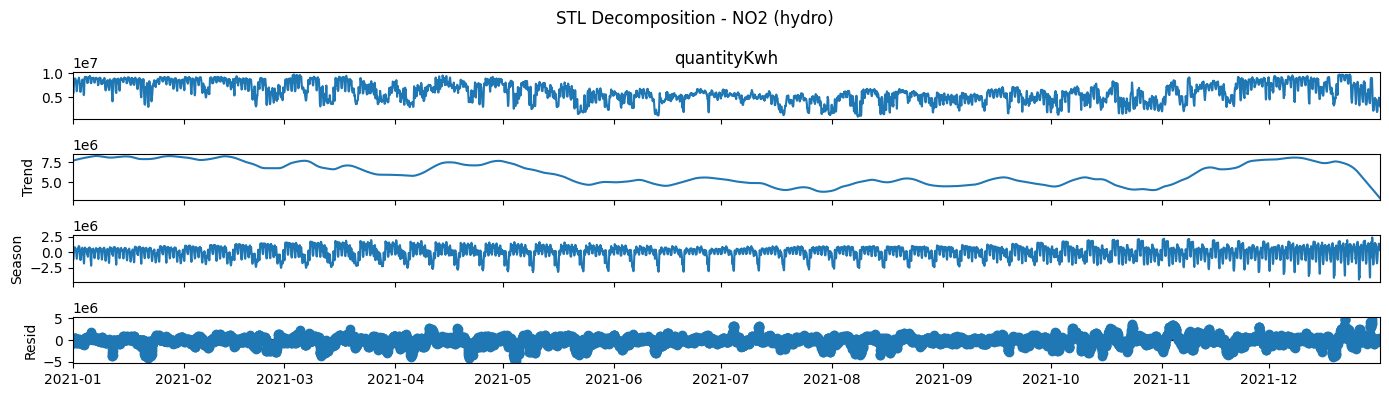

✅ STL decomposition complete for NO2 - hydro


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def stl_decompose_elhub_from_csv(csv_path: str,
                                 price_area: str,
                                 production_group: str,
                                 period: int = 24 * 7,
                                 seasonal: int = 13,
                                 trend: int = 301,
                                 robust: bool = True):
    """
    Perform STL decomposition on Elhub CSV data using original column names.
    """

    # Load CSV
    df = pd.read_csv(csv_path)

    # Convert startTime to datetime (UTC)
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True)

    # Filter by price area and production group
    df_filtered = df[
        (df["priceArea"] == price_area) &
        (df["productionGroup"] == production_group)
    ][["startTime", "quantityKwh"]].dropna().sort_values("startTime")

    if df_filtered.empty:
        raise ValueError(f"No matching data found for {price_area} - {production_group}")

    # Prepare hourly time series
    series = df_filtered.set_index("startTime")["quantityKwh"].asfreq("h").interpolate(method="time")


    if period < 2:
        raise ValueError("period must be >= 2")

    # Ensure trend > period
    
    if trend <= period:
        trend = period + 1 if period % 2 == 0 else period + 2
        print(f"⚠️ Adjusted trend to {trend} (must be > period)")
        
    if trend % 2 == 0:
        trend += 1  # ensure odd number

    # Ensure seasonal is odd and >=3
    if seasonal < 3:
        seasonal = 3
    if seasonal % 2 == 0:
        seasonal += 1
        
        
        
    # STL decomposition
    stl = STL(series, period=period, seasonal=seasonal, trend=trend, robust=robust)
    result = stl.fit()

    # Plot
    fig = result.plot()
    fig.suptitle(f"STL Decomposition - {price_area} ({production_group})", fontsize=12)
    fig.tight_layout()
    plt.show()

    print(f"✅ STL decomposition complete for {price_area} - {production_group}")
    return fig

# Example usage
fig = stl_decompose_elhub_from_csv(
    "elhub_2021_production.csv",
    "NO2",
    "hydro"
)


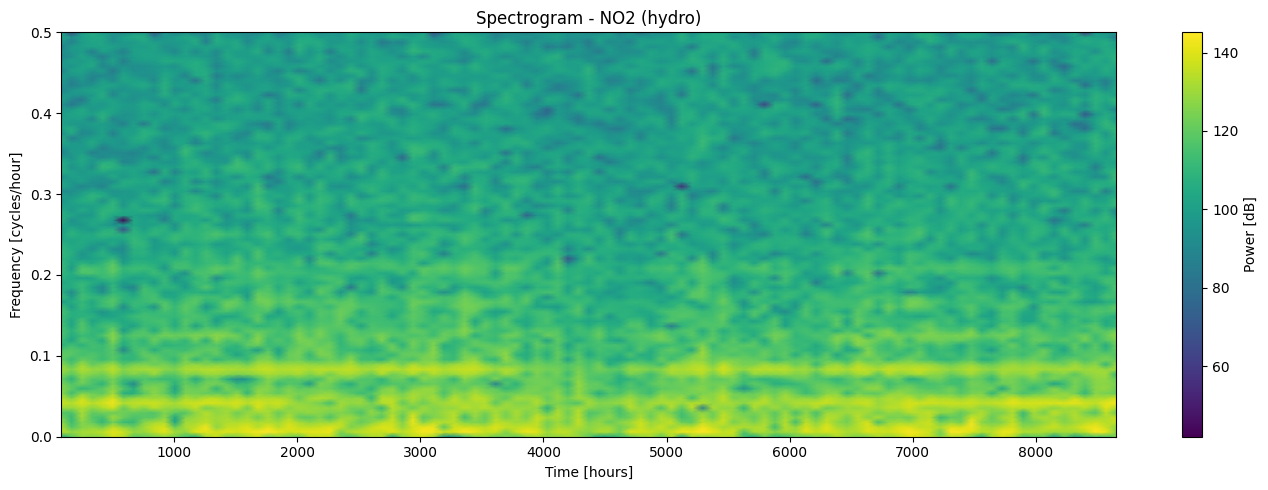

✅ Spectrogram complete for NO2 - hydro


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import numpy as np

def elhub_spectrogram(csv_path: str,
                      price_area: str,
                      production_group: str,
                      window_length: int = 168,   # default: 1 week (hourly data)
                      window_overlap: int = 84):  # default: 50% overlap
    """
    Compute and plot a spectrogram for Elhub CSV production data.

    Parameters:
        csv_path (str): Path to Elhub CSV file.
        price_area (str): Price area code (e.g., 'NO1', 'NO2').
        production_group (str): Production group (e.g., 'hydro', 'wind').
        window_length (int): Segment length (samples per FFT window).
        window_overlap (int): Number of overlapping samples between windows.

    Returns:
        fig (matplotlib.figure.Figure): Spectrogram figure.
    """

    # --- Load and prepare data ---
    df = pd.read_csv(csv_path)
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True)

    df_filtered = df[
        (df["priceArea"] == price_area) &
        (df["productionGroup"] == production_group)
    ][["startTime", "quantityKwh"]].dropna().sort_values("startTime")

    if df_filtered.empty:
        raise ValueError(f"No matching data found for {price_area} - {production_group}")

    series = (
        df_filtered.set_index("startTime")["quantityKwh"]
        .asfreq("h")
        .interpolate(method="time")
    )
    data = series.values
    n = len(data)

    # --- Validate parameters ---
    if window_length >= n:
        raise ValueError(f"window_length ({window_length}) must be smaller than number of samples ({n})")
    if window_overlap >= window_length:
        raise ValueError("window_overlap must be smaller than window_length")

    # --- Compute spectrogram ---
    f, t, Sxx = spectrogram(
        data,
        fs=1.0,                # 1 sample per hour
        window='hann',
        nperseg=window_length,
        noverlap=window_overlap,
        scaling='density',
        mode='psd'
    )

    # Prevent log of zero
    Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis')
    ax.set_ylabel('Frequency [cycles/hour]')
    ax.set_xlabel('Time [hours]')
    ax.set_title(f"Spectrogram - {price_area} ({production_group})")
    fig.colorbar(im, ax=ax, label='Power [dB]')
    fig.tight_layout()
    plt.show()

    print(f"✅ Spectrogram complete for {price_area} - {production_group}")
    return fig


# --- Example usage ---
fig = elhub_spectrogram(
    csv_path="elhub_2021_production.csv",
    price_area="NO2",
    production_group="hydro",
    window_length=168,
    window_overlap=84
)
